# Descripción del proyecto

La compañía Sweet Lift Taxi ha recopilado datos históricos sobre pedidos de taxis en los aeropuertos. Para atraer a más conductores durante las horas pico, necesitamos predecir la cantidad de pedidos de taxis para la próxima hora. Construye un modelo para dicha predicción.

La métrica RECM en el conjunto de prueba no debe ser superior a 48.

## Instrucciones del proyecto.

1. Descarga los datos y haz el remuestreo por una hora.
2. Analiza los datos
3. Entrena diferentes modelos con diferentes hiperparámetros. La muestra de prueba debe ser el 10% del conjunto de datos inicial.4. Prueba los datos usando la muestra de prueba y proporciona una conclusión.

## Descripción de los datos

Los datos se almacenan en el archivo `taxi.csv`. 	
El número de pedidos está en la columna `num_orders`.

## Preparación

In [113]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import lightgbm as lgb
from sklearn.metrics import mean_squared_error

In [114]:
df = pd.read_csv('/datasets/taxi.csv', index_col=[0],  parse_dates=[0])
df.info()
df.sort_index(inplace=True)
df = df.resample('1H').sum()
print(df.head())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 26496 entries, 2018-03-01 00:00:00 to 2018-08-31 23:50:00
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   num_orders  26496 non-null  int64
dtypes: int64(1)
memory usage: 414.0 KB
                     num_orders
datetime                       
2018-03-01 00:00:00         124
2018-03-01 01:00:00          85
2018-03-01 02:00:00          71
2018-03-01 03:00:00          66
2018-03-01 04:00:00          43


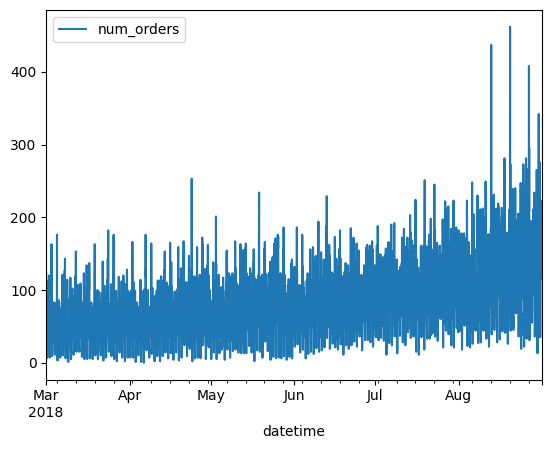

In [115]:
df.plot()
plt.show()

## Análisis

In [116]:
def make_features(data, max_lag, rolling_mean_size):
    data['year'] = data.index.year
    data['month'] = data.index.month
    data['day'] = data.index.day
    data['dayofweek'] = data.index.dayofweek

    for lag in range(1, max_lag + 1):
        data['lag_{}'.format(lag)] = data['num_orders'].shift(lag)

    data['rolling_mean'] = (
        data['num_orders'].shift().rolling(rolling_mean_size).mean()
    )

    data['std'] = data['num_orders'].shift().rolling(rolling_mean_size).std()
    data['max'] = data['num_orders'].shift().rolling(rolling_mean_size).max()
    data['min'] = data['num_orders'].shift().rolling(rolling_mean_size).min()

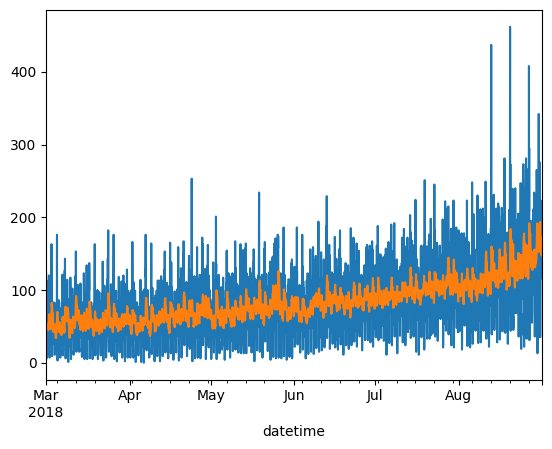

In [117]:
make_features(df, 30, 15)
df['num_orders'].plot()
df['rolling_mean'].plot()
plt.show()
#print(df.head(10))

In [118]:
train, test = train_test_split(df, shuffle=False, test_size=0.1)
train = train.dropna()

In [132]:
features_train = train.drop('num_orders',axis=1)
target_train = train['num_orders']
print(features_train.head(3))
print()
print(target_train.head(3))

                     year  month  day  dayofweek  lag_1  lag_2  lag_3  lag_4  \
datetime                                                                       
2018-03-02 06:00:00  2018      3    2          4   11.0   20.0   64.0   75.0   
2018-03-02 07:00:00  2018      3    2          4   11.0   11.0   20.0   64.0   
2018-03-02 08:00:00  2018      3    2          4    7.0   11.0   11.0   20.0   

                     lag_5  lag_6  ...  lag_25  lag_26  lag_27  lag_28  \
datetime                           ...                                   
2018-03-02 06:00:00  120.0   90.0  ...     6.0    43.0    66.0    71.0   
2018-03-02 07:00:00   75.0  120.0  ...    12.0     6.0    43.0    66.0   
2018-03-02 08:00:00   64.0   75.0  ...    15.0    12.0     6.0    43.0   

                     lag_29  lag_30  rolling_mean        std    max   min  
datetime                                                                   
2018-03-02 06:00:00    85.0   124.0     63.266667  29.769271  120.0  11.0  


In [133]:
features_test = test.drop('num_orders',axis=1)
target_test = test['num_orders']
print(features_test.head(3))
print()
print(target_test.head(3))

                     year  month  day  dayofweek  lag_1  lag_2  lag_3  lag_4  \
datetime                                                                       
2018-08-13 14:00:00  2018      8   13          0  119.0   92.0  144.0  156.0   
2018-08-13 15:00:00  2018      8   13          0  102.0  119.0   92.0  144.0   
2018-08-13 16:00:00  2018      8   13          0  175.0  102.0  119.0   92.0   

                     lag_5  lag_6  ...  lag_25  lag_26  lag_27  lag_28  \
datetime                           ...                                   
2018-08-13 14:00:00  137.0   91.0  ...   120.0   123.0    81.0   108.0   
2018-08-13 15:00:00  156.0  137.0  ...   104.0   120.0   123.0    81.0   
2018-08-13 16:00:00  144.0  156.0  ...   149.0   104.0   120.0   123.0   

                     lag_29  lag_30  rolling_mean        std    max   min  
datetime                                                                   
2018-08-13 14:00:00   108.0    97.0    152.866667  96.727058  437.0  39.0  


## Formación

Los datos de los hiperparametros fueron tomados por experiencia en proyectos anteriores, especificamente del proyecto anterior para cada uno de los casos.

In [125]:
model = LinearRegression()
model.fit(features_train,target_train)
predict = model.predict(features_train)
print("RECM para el conjunto de entrenamiento:", mean_squared_error(target_train,predict)**0.5)
predict = model.predict(features_test)
print("RECM para el conjunto de prueba:", mean_squared_error(target_test,predict)**0.5)

RECM para el conjunto de entrenamiento: 25.209747952181782
RECM para el conjunto de prueba: 47.10805910129695


In [126]:
model = DecisionTreeRegressor(max_depth=10)
model.fit(features_train,target_train) 
predict = model.predict(features_train)
print("RECM para el conjunto de prueba:", mean_squared_error(target_train,predict)**0.5)
predict = model.predict(features_test)
print("RECM para el conjunto de prueba:", mean_squared_error(target_test,predict)**0.5)

RECM para el conjunto de prueba: 15.373435919261794
RECM para el conjunto de prueba: 53.74194186784425


In [127]:
model = RandomForestRegressor(n_estimators=50,max_depth=10)
model.fit(features_train,target_train) 
predict = model.predict(features_train)
print("RECM para el conjunto de prueba:", mean_squared_error(target_train,predict)**0.5)
predict = model.predict(features_test)
print("RECM para el conjunto de prueba:", mean_squared_error(target_test,predict)**0.5)

RECM para el conjunto de prueba: 14.222682103170985
RECM para el conjunto de prueba: 46.17575587115846


In [134]:
model = lgb.LGBMRegressor(
            boosting_type='gbdt',
            num_leaves=50,
            learning_rate=0.05,
            n_estimators=200,
        )
model.fit(features_train, target_train)
predict = model.predict(features_train)
print("RECM para el conjunto de prueba:", mean_squared_error(target_train,predict)**0.5)
predict = model.predict(features_test)
print("RECM para el conjunto de prueba:", mean_squared_error(target_test,predict)**0.5)

RECM para el conjunto de prueba: 8.796852783973486
RECM para el conjunto de prueba: 44.08434622649404


## Prueba

Ya que todos los modelos, excepto el arbol de decisiones; dieron un buen resultado me tome la libertad de tomar el de progrecion de gradiante ya que fue el mejor

In [135]:
# Se toma en cuenta el modelo de progresion de gradiante de la libreria LightGBM 
predict = model.predict(features_test)
print("RECM para el conjunto de prueba:", mean_squared_error(target_test,predict)**0.5)

RECM para el conjunto de prueba: 44.08434622649404


## Conclusion

En este proyecto trabaje con series temporales, con el proposito de ayudar a una agencia de taxis a predecir las siguente cantidad de ordenes de viajes con datos historicos.

Para esto aplique lo necesario para acoplar los datos y combertirlos en series temporales, al mismo tiempo para complementar las caracteristicas, agregue una cantidad grnade de lags para ayudar a una mejor prediccion y mas datos estadisticos como el maximo, el minimo y la desviacion estandar, ademas del promedio.

Probe diferentes modelos incluyendo la progresion de gradiante y esta fue la de mejor resultados a pesar que la mayoria ya habian superado el umbral necesario y solicitado para este proyecto.

Puedo decir que tranajar con series temporales es un tanto diferente a lo que se conocia mas que nada por el acoplamiento de datos y de como trabajarlos pero de ahi en fuera, todo es lo mismo y, si, aplicamos los conocimientos necesarios podemo obtener buenos resultados.

# Lista de revisión

- [x]  	
Jupyter Notebook está abierto.
- [X]  El código no tiene errores
- [X]  Las celdas con el código han sido colocadas en el orden de ejecución.
- [X]  	
Los datos han sido descargados y preparados.
- [X]  Se ha realizado el paso 2: los datos han sido analizados
- [X]  Se entrenó el modelo y se seleccionaron los hiperparámetros
- [X]  Se han evaluado los modelos. Se expuso una conclusión
- [X] La *RECM* para el conjunto de prueba no es más de 48